## 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("unified_features_v2.csv")
print(f"Total rows loaded: {len(df)}")
print(df["traffic_source"].value_counts())
df.head()

Total rows loaded: 1039
traffic_source
DCC_2024_2025    973
SDCC_2024         65
DLR_2023           1
Name: count, dtype: int64


,location_id,lat,lon,traffic_volume,traffic_source,charger_count_nearby,road_density,ev_penetration_proxy
0,1,53.348754,-6.257607,241.52,DCC_2024_2025,0,219,0.049
1,2,53.354711,-6.246679,1540.22,DCC_2024_2025,0,63,0.049
2,3,53.351374,-6.250073,833.42,DCC_2024_2025,0,138,0.049
3,4,53.361145,-6.240513,289.96,DCC_2024_2025,0,49,0.049
4,5,53.355797,-6.292406,769.61,DCC_2024_2025,1,24,0.049


## 2. Separate SDCC (Display-Only)

SDCC uses the SCOOT sensor system; DCC/DLR use SCATS. Mean traffic volume: SDCC=142 vs DCC=701 (~5x difference). Root cause unclear (genuine low traffic or incompatible systems). Decision: exclude SDCC from clustering; show on map only.

In [2]:
df_sdcc    = df[df["traffic_source"] == "SDCC_2024"].copy()
df_cluster = df[df["traffic_source"] != "SDCC_2024"].copy().reset_index(drop=True)

print(f"Clustering dataset : {len(df_cluster)} rows (DCC + DLR)")
print(f"SDCC display-only  : {len(df_sdcc)} rows")
print(f"\nDCC/DLR mean traffic : {df_cluster['traffic_volume'].mean():.1f}")
print(f"SDCC mean traffic    : {df_sdcc['traffic_volume'].mean():.1f}")

Clustering dataset : 974 rows (DCC + DLR)
SDCC display-only  : 65 rows

DCC/DLR mean traffic : 700.8
SDCC mean traffic    : 142.1


## 3. Feature Engineering — Gap Score

`gap_score = traffic_volume / (charger_count_nearby + 1)`

Higher score = high demand, low existing supply = priority candidate.

In [3]:
df_cluster["gap_score"] = (
    df_cluster["traffic_volume"] / (df_cluster["charger_count_nearby"] + 1)
)
print("Gap Score statistics:")
print(df_cluster["gap_score"].describe())

Gap Score statistics:
count     974.000000
mean      544.962229
std       524.613235
min         0.000000
25%       185.690833
50%       421.301667
75%       795.037500
max      7731.500000
Name: gap_score, dtype: float64


## 4. Select Top 20% Candidates by Gap Score

In [4]:
threshold = df_cluster["gap_score"].quantile(0.80)
df_priority = df_cluster[df_cluster["gap_score"] >= threshold].copy().reset_index(drop=True)

print(f"Gap score threshold (80th percentile): {threshold:.2f}")
print(f"Candidate sites selected: {len(df_priority)} / {len(df_cluster)}")

Gap score threshold (80th percentile): 891.43
Candidate sites selected: 195 / 974


## 5. Elbow Method — Select Optimal K

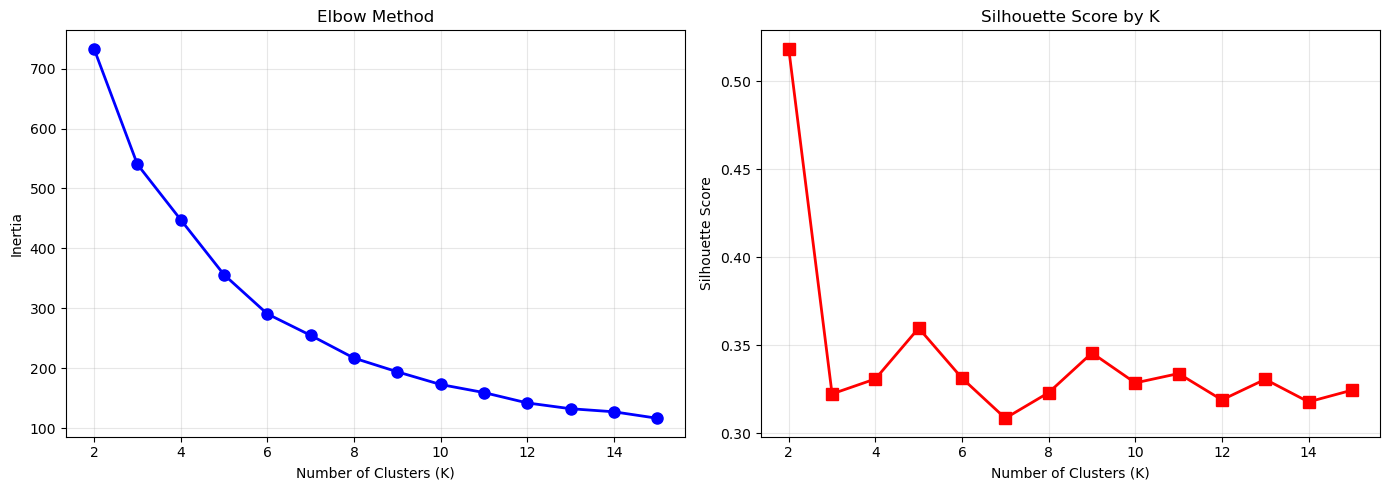


Silhouette scores by K:
  K= 2: 0.5185
  K= 3: 0.3225
  K= 4: 0.3310
  K= 5: 0.3599
  K= 6: 0.3314
  K= 7: 0.3086
  K= 8: 0.3232
  K= 9: 0.3457
  K=10: 0.3287
  K=11: 0.3340
  K=12: 0.3191
  K=13: 0.3308
  K=14: 0.3179
  K=15: 0.3246


In [5]:
FEATURES = ["traffic_volume", "charger_count_nearby", "road_density", "lat", "lon"]
# ev_penetration_proxy excluded: constant 0.049, zero spatial variance

X = df_priority[FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
sil_scores = []
K_range = range(2, 16)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")
ax1.grid(True, alpha=0.3)
ax2.plot(K_range, sil_scores, "rs-", linewidth=2, markersize=8)
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score by K")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_silhouette_v2.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSilhouette scores by K:")
for k, s in zip(K_range, sil_scores):
    print(f"  K={k:2d}: {s:.4f}")

## 6. Final K-Means (K=10)

In [6]:
K = 10
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_priority["cluster"] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df_priority["cluster"])
print(f"Silhouette Score (K={K}): {score:.4f}")
print(f"\nComparison:")
print(f"  Interim v1 (223 sites, DLR only) : 0.4235")
print(f"  v2         (974 sites, DCC+DLR)  : {score:.4f}")
print(f"\nNote: Score decrease expected — 4x more sites, larger geographic area.")
print(f"\nCluster sizes:")
print(df_priority["cluster"].value_counts().sort_index())

Silhouette Score (K=10): 0.3287

Comparison:
  Interim v1 (223 sites, DLR only) : 0.4235
  v2         (974 sites, DCC+DLR)  : 0.3287

Note: Score decrease expected — 4x more sites, larger geographic area.

Cluster sizes:
cluster
0    27
1    37
2    13
3     4
4    26
5     8
6    10
7     1
8    36
9    33
Name: count, dtype: int64


## 7. Select Top Recommendation per Cluster

In [7]:
cluster_centers = (
    df_priority
    .sort_values("gap_score", ascending=False)
    .groupby("cluster")
    .first()
    .reset_index()
)
cluster_centers = cluster_centers.sort_values("gap_score", ascending=False).reset_index(drop=True)
cluster_centers["rank"] = cluster_centers.index + 1

print("Top 10 Recommendations:")
cols = ["rank","lat","lon","cluster","gap_score","traffic_volume","charger_count_nearby","road_density"]
print(cluster_centers[cols].to_string(index=False))

Top 10 Recommendations:
 rank       lat       lon  cluster  gap_score  traffic_volume  charger_count_nearby  road_density
    1 53.425378 -6.219091        7   7731.500         7731.50                     0             3
    2 53.343710 -6.308068        6   3157.070         3157.07                     0            95
    3 53.264716 -6.133623        4   2376.650         2376.65                     0            30
    4 53.403009 -6.310221        0   2179.210         2179.21                     0            43
    5 53.382460 -6.244531        1   2143.840         2143.84                     0            31
    6 53.405293 -6.265217        9   1944.880         1944.88                     0            52
    7 53.313654 -6.222392        8   1588.050         1588.05                     0            41
    8 53.246493 -6.138492        2   1487.735         2975.47                     1            48
    9 53.353031 -6.256035        5   1375.220         1375.22                     0           

## 8. Export recommendations.csv

In [8]:
out_cols = ["rank","lat","lon","cluster","gap_score","traffic_volume","charger_count_nearby","road_density","traffic_source"]
cluster_centers[out_cols].to_csv("recommendations.csv", index=False)
print("Saved: recommendations.csv")

Saved: recommendations.csv


## 9. Folium Map

In [9]:
COLORS = [
    "red", "blue", "green", "purple", "orange",
    "darkred", "cadetblue", "darkgreen", "darkpurple", "darkblue"
]

m = folium.Map(location=[53.33, -6.25], zoom_start=11)

# All DCC+DLR sites (grey)
for _, row in df_cluster.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3, color="lightgrey", fill=True, fill_opacity=0.3
    ).add_to(m)

# SDCC sites (blue outline, display only)
for _, row in df_sdcc.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=4, color="steelblue", fill=False, weight=1.5,
        popup=f"SDCC (display only)<br>Traffic: {row['traffic_volume']:.0f}"
    ).add_to(m)

# Priority candidates (coloured by cluster)
for _, row in df_priority.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5, color=COLORS[int(row["cluster"])], fill=True, fill_opacity=0.5,
        popup=f"Traffic: {row['traffic_volume']:.0f}<br>Gap Score: {row['gap_score']:.1f}<br>Cluster: {int(row['cluster'])}"
    ).add_to(m)

# Recommendations (red bolt markers)
for _, row in cluster_centers.iterrows():
    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=f"Rank #{int(row['rank'])}<br>Traffic: {row['traffic_volume']:.0f}<br>Gap Score: {row['gap_score']:.1f}",
        icon=folium.Icon(color="red", icon="bolt", prefix="fa")
    ).add_to(m)

m.save("kmeans_recommendations_v2.html")
print("Map saved: kmeans_recommendations_v2.html")
m

Map saved: kmeans_recommendations_v2.html


## 10. Summary

In [10]:
print("=== K-Means Clustering Summary (v2) ===")
print(f"Total SCATS sites loaded     : {len(df)}")
print(f"SDCC excluded (display only) : {len(df_sdcc)}")
print(f"Clustering dataset           : {len(df_cluster)} (DCC + DLR)")
print(f"Priority sites (top 20%)     : {len(df_priority)}")
print(f"Number of clusters (K)       : {K}")
print(f"Silhouette Score             : {score:.4f}")
print(f"Recommended locations        : {len(cluster_centers)}")
print()
print("Top 3 recommendations:")
for _, row in cluster_centers.head(3).iterrows():
    print(f"  Rank #{int(row['rank'])}: ({row['lat']:.4f}, {row['lon']:.4f}) — Gap Score: {row['gap_score']:.1f}")

=== K-Means Clustering Summary (v2) ===
Total SCATS sites loaded     : 1039
SDCC excluded (display only) : 65
Clustering dataset           : 974 (DCC + DLR)
Priority sites (top 20%)     : 195
Number of clusters (K)       : 10
Silhouette Score             : 0.3287
Recommended locations        : 10

Top 3 recommendations:
  Rank #1: (53.4254, -6.2191) — Gap Score: 7731.5
  Rank #2: (53.3437, -6.3081) — Gap Score: 3157.1
  Rank #3: (53.2647, -6.1336) — Gap Score: 2376.7
